## Agent-Eval Test Comparison

- Test 1: RETRIEVAL_K = 2
- Test 2: RETRIEVAL_K = 4
- Test 3: RETRIEVAL_K = 6

# Test Results Comparison

This notebook visualizes and compares the results from multiple test runs of the AI insurance agent evaluation system. It loads test results from `results.json` and generates comprehensive line graphs comparing performance metrics across different configurations.

## What This Notebook Presents

The notebook compares **3 test cases** that differ by their `Retrieval_K` parameter (values: 2, 4, and 6) while keeping `Temperature` constant at 0.1. For each test case, it visualizes:

1. **Overall Success Rate** - Percentage of tests that passed (10 total tests per case)
2. **RAG Metrics** - Two key metrics for Retrieval-Augmented Generation performance:
   - **Context Precision** - Average precision of retrieved contexts
   - **Answer Relevance** - Average relevance of generated answers
3. **Execution Time** - Total time taken to run all tests (in seconds and minutes)
4. **Combined View** - A 2x2 grid showing all metrics side-by-side for easy comparison

## Visualizations

- **Line graphs** showing how metrics change as `Retrieval_K` increases
- **Annotated data points** with exact values for easy reading
- **Summary statistics** highlighting the best performing configuration for each metric

## Purpose

This analysis helps identify the optimal `Retrieval_K` value by examining the trade-offs between:
- Test success rate
- Retrieval quality (context precision)
- Answer quality (answer relevance)
- Execution performance (time)

Use the visualizations to understand how changing the retrieval parameter affects system performance across these dimensions.


In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [3]:
# Common plotting functions

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

def plot_line_with_annotations(ax, x, y, color, marker='o', label=None, 
                                annotation_format='.2f', y_offset=10, 
                                fontsize=9, fontweight='bold', 
                                df=None, x_col=None, minutes_col=None):
    """
    Plot a line graph with value annotations on each point.
    
    Parameters:
    - ax: matplotlib axis object
    - x: x-axis values (pandas Series or array-like)
    - y: y-axis values (pandas Series or array-like)
    - color: line/marker color
    - marker: marker style (default 'o')
    - label: legend label
    - annotation_format: format string for annotations (e.g., '.1%', '.2f', 'time')
    - y_offset: vertical offset for annotations
    - fontsize: annotation font size
    - fontweight: annotation font weight
    - df: DataFrame for time annotations with minutes (optional)
    - x_col: column name in df for x-axis matching (for time annotations)
    - minutes_col: column name for minutes if df provided
    """
    ax.plot(x, y, marker=marker, linewidth=2, markersize=10, 
            color=color, label=label, linestyle='-')
    
    # Add value labels on points
    x_values = list(x)
    y_values = list(y)
    for idx, (xi, yi) in enumerate(zip(x_values, y_values)):
        if '%' in annotation_format:
            label_text = f"{yi:.1%}"
        elif annotation_format == 'time':
            # For time annotations with minutes
            if df is not None and x_col is not None and minutes_col is not None:
                df_row = df[df[x_col] == xi]
                if not df_row.empty:
                    minutes = df_row[minutes_col].values[0]
                    label_text = f"{yi:.1f}s\n({minutes:.2f} min)"
                else:
                    label_text = f"{yi:.1f}s"
            else:
                label_text = f"{yi:.0f}s"
        else:
            label_text = f"{yi:{annotation_format}}"
        
        ax.annotate(label_text, 
                    (xi, yi),
                    textcoords="offset points", 
                    xytext=(0, y_offset), 
                    ha='center', 
                    fontsize=fontsize, 
                    fontweight=fontweight,
                    color=color)


def setup_axis_labels(ax, xlabel, ylabel, title, x_ticks=None, y_lim=None, 
                     fontsize_title=14, fontsize_labels=12, title_pad=20):
    """
    Set up common axis properties (labels, title, ticks, limits, grid).
    
    Parameters:
    - ax: matplotlib axis object
    - xlabel: x-axis label
    - ylabel: y-axis label
    - title: plot title
    - x_ticks: x-axis tick values (if None, uses auto)
    - y_lim: tuple (ymin, ymax) for y-axis limits
    - fontsize_title: title font size
    - fontsize_labels: label font size
    - title_pad: padding for title
    """
    ax.set_xlabel(xlabel, fontsize=fontsize_labels, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=fontsize_labels, fontweight='bold')
    ax.set_title(title, fontsize=fontsize_title, fontweight='bold', pad=title_pad)
    
    if x_ticks is not None:
        ax.set_xticks(x_ticks)
    if y_lim is not None:
        ax.set_ylim(y_lim)
    
    ax.grid(True, alpha=0.3, linestyle='--')


def plot_metric(df, x_col, y_col, color, title, ylabel, 
                annotation_format='.2f', y_lim=None, figsize=(10, 6),
                show_legend=True, legend_label=None, minutes_col=None):
    """
    Create a complete line plot for a single metric.
    
    Parameters:
    - df: DataFrame with data
    - x_col: column name for x-axis
    - y_col: column name for y-axis
    - color: line/marker color
    - title: plot title
    - ylabel: y-axis label
    - annotation_format: format string for value annotations ('time' for time with minutes)
    - y_lim: tuple (ymin, ymax) for y-axis limits
    - figsize: figure size tuple
    - show_legend: whether to show legend
    - legend_label: label for legend
    - minutes_col: column name for minutes if annotation_format is 'time'
    
    Returns:
    - fig, ax: figure and axis objects
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    plot_line_with_annotations(ax, df[x_col], df[y_col], color, 
                               label=legend_label or ylabel,
                               annotation_format=annotation_format,
                               df=df if annotation_format == 'time' else None,
                               x_col=x_col if annotation_format == 'time' else None,
                               minutes_col=minutes_col)
    
    setup_axis_labels(ax, 'Retrieval K', ylabel, title, 
                     x_ticks=df[x_col].values, y_lim=y_lim)
    
    if show_legend:
        ax.legend(fontsize=11, loc='best')
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax


def plot_dual_metrics(df, x_col, y1_col, y2_col, color1, color2, 
                      label1, label2, title, ylabel='Score',
                      annotation_format1='.2f', annotation_format2='.2f',
                      y_lim=None, figsize=(10, 6)):
    """
    Create a line plot with two metrics on the same axes.
    
    Parameters:
    - df: DataFrame with data
    - x_col: column name for x-axis
    - y1_col: column name for first y-axis metric
    - y2_col: column name for second y-axis metric
    - color1: color for first line
    - color2: color for second line
    - label1: label for first line
    - label2: label for second line
    - title: plot title
    - ylabel: y-axis label
    - annotation_format1: format for first metric annotations
    - annotation_format2: format for second metric annotations
    - y_lim: tuple (ymin, ymax) for y-axis limits
    - figsize: figure size tuple
    
    Returns:
    - fig, ax: figure and axis objects
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    plot_line_with_annotations(ax, df[x_col], df[y1_col], color1, 
                               marker='o', label=label1,
                               annotation_format=annotation_format1, y_offset=10,
                               df=df if annotation_format1 == 'time' else None,
                               x_col=x_col if annotation_format1 == 'time' else None)
    
    plot_line_with_annotations(ax, df[x_col], df[y2_col], color2, 
                               marker='s', label=label2,
                               annotation_format=annotation_format2, y_offset=-15,
                               df=df if annotation_format2 == 'time' else None,
                               x_col=x_col if annotation_format2 == 'time' else None)
    
    setup_axis_labels(ax, 'Retrieval K', ylabel, title,
                     x_ticks=df[x_col].values, y_lim=y_lim)
    
    ax.legend(fontsize=11, loc='best')
    plt.tight_layout()
    plt.show()
    
    return fig, ax


def plot_subplot_metric(ax, df, x_col, y_col, color, title, ylabel,
                         annotation_format='.2f', y_lim=None,
                         fontsize_title=12, fontsize_labels=11,
                         show_legend=False, minutes_col=None):
    """
    Plot a single metric on a subplot axis (for use in combined views).
    
    Parameters:
    - ax: matplotlib axis object (subplot)
    - df: DataFrame with data
    - x_col: column name for x-axis
    - y_col: column name for y-axis
    - color: line/marker color
    - title: plot title
    - ylabel: y-axis label
    - annotation_format: format string for value annotations
    - y_lim: tuple (ymin, ymax) for y-axis limits
    - fontsize_title: title font size
    - fontsize_labels: label font size
    - show_legend: whether to show legend
    - minutes_col: column name for minutes if annotation_format is 'time'
    """
    plot_line_with_annotations(ax, df[x_col], df[y_col], color, 
                               annotation_format=annotation_format,
                               df=df if annotation_format == 'time' else None,
                               x_col=x_col if annotation_format == 'time' else None,
                               minutes_col=minutes_col,
                               fontsize=9, y_offset=10)
    
    setup_axis_labels(ax, 'Retrieval K', ylabel, title,
                     x_ticks=df[x_col].values, y_lim=y_lim,
                     fontsize_title=fontsize_title, 
                     fontsize_labels=fontsize_labels,
                     title_pad=15)


In [4]:
# Load results.json
results_file = Path('results.json')

with open(results_file, 'r') as f:
    data = json.load(f)

print(f"Loaded {len(data['test_cases'])} test cases")
print("\nTest configurations:")
for case in data['test_cases']:
    print(f"  Test {case['test_number']}: Temperature={case['configuration']['temperature']}, Retrieval_K={case['configuration']['retrieval_k']}")


Loaded 3 test cases

Test configurations:
  Test 1: Temperature=0.1, Retrieval_K=2
  Test 2: Temperature=0.1, Retrieval_K=4
  Test 3: Temperature=0.1, Retrieval_K=6


In [5]:
# Convert to DataFrame for easier manipulation
df = pd.DataFrame([
    {
        'Test': case['test_number'],
        'Retrieval_K': case['configuration']['retrieval_k'],
        'Temperature': case['configuration']['temperature'],
        'Success_Rate': case['metrics']['success_rate'],
        'Passed': case['metrics']['passed'],
        'Failed': case['metrics']['failed'],
        'Context_Precision': case['rag_metrics']['avg_context_precision'],
        'Answer_Relevance': case['rag_metrics']['avg_answer_relevance'],
        'Time_Seconds': case['elapsed_time']['seconds'],
        'Time_Minutes': case['elapsed_time']['minutes']
    }
    for case in data['test_cases']
])

df = df.sort_values('Retrieval_K')  # Sort by Retrieval_K for proper line graph order
df


,Test,Retrieval_K,Temperature,Success_Rate,Passed,Failed,Context_Precision,Answer_Relevance,Time_Seconds,Time_Minutes
0,1,2,0.1,1.0,10,0,0.94,0.82,170.93,2.85
1,2,4,0.1,0.9,9,1,0.89,0.77,223.31,3.72
2,3,6,0.1,0.8,8,2,0.72,0.82,81.72,1.36


## Overall Success Rate Comparison


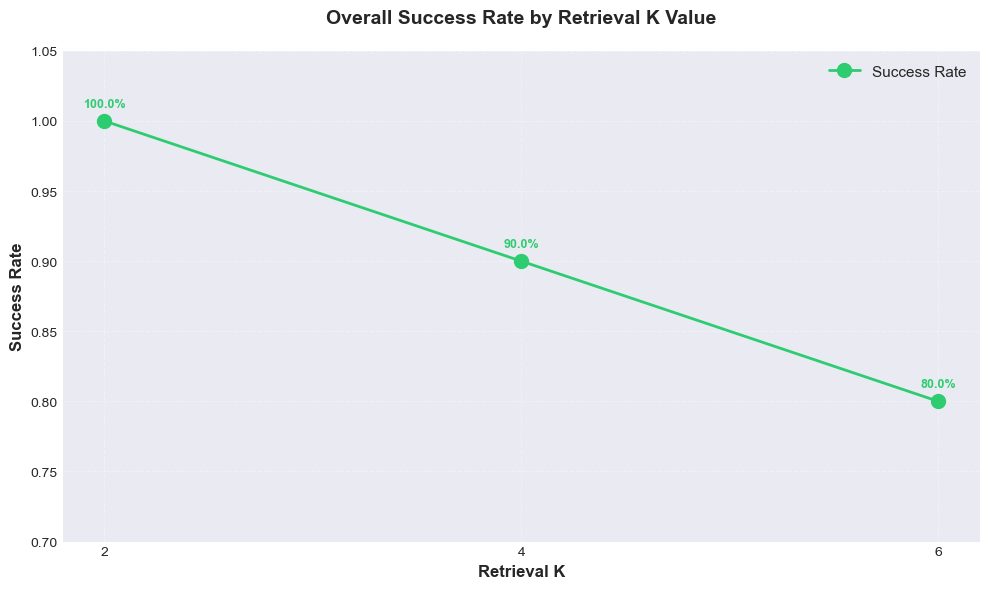

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Overall Success Rate by Retrieval K Value'}, xlabel='Retrieval K', ylabel='Success Rate'>)

In [6]:
plot_metric(df, 'Retrieval_K', 'Success_Rate', '#2ecc71',
            'Overall Success Rate by Retrieval K Value', 'Success Rate',
            annotation_format='.1%', y_lim=(0.7, 1.05),
            legend_label='Success Rate')


## RAG Metrics Comparison (Context Precision & Answer Relevance)


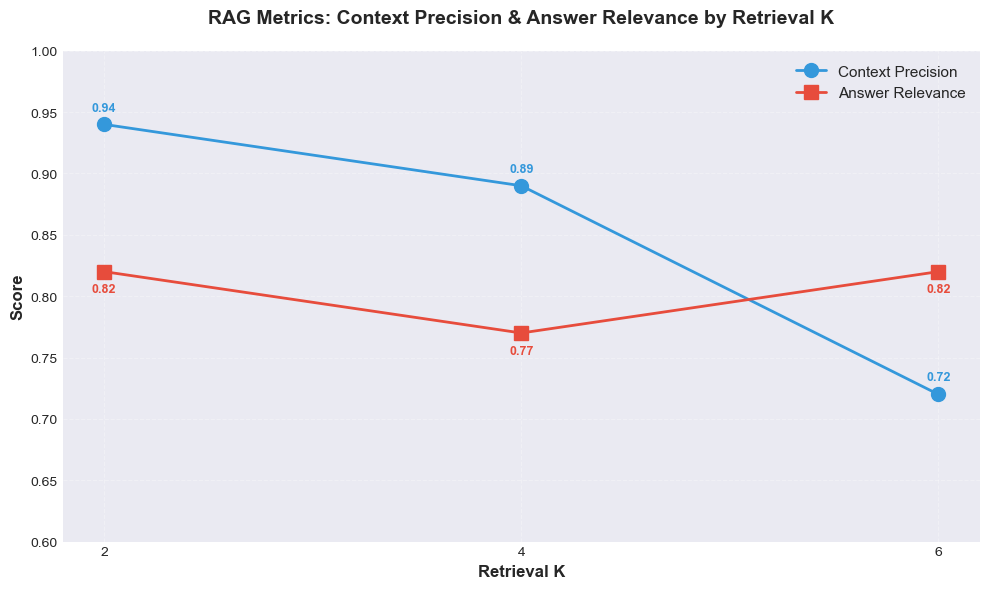

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'RAG Metrics: Context Precision & Answer Relevance by Retrieval K'}, xlabel='Retrieval K', ylabel='Score'>)

In [7]:
plot_dual_metrics(df, 'Retrieval_K', 'Context_Precision', 'Answer_Relevance',
                  '#3498db', '#e74c3c', 'Context Precision', 'Answer Relevance',
                  'RAG Metrics: Context Precision & Answer Relevance by Retrieval K',
                  ylabel='Score', annotation_format1='.2f', annotation_format2='.2f',
                  y_lim=(0.6, 1.0))


## Execution Time Comparison


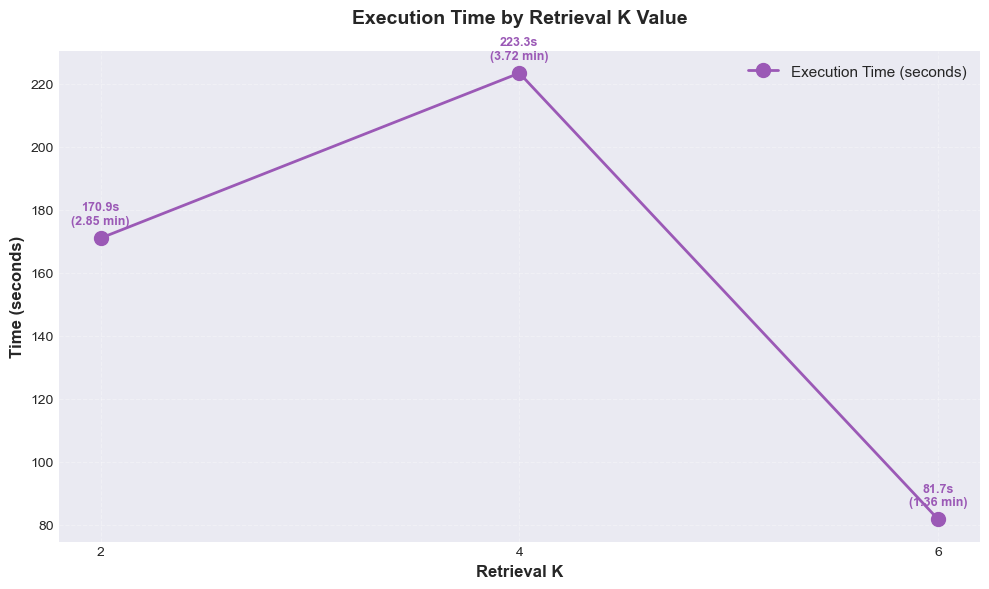

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Execution Time by Retrieval K Value'}, xlabel='Retrieval K', ylabel='Time (seconds)'>)

In [8]:
plot_metric(df, 'Retrieval_K', 'Time_Seconds', '#9b59b6',
            'Execution Time by Retrieval K Value', 'Time (seconds)',
            annotation_format='time', minutes_col='Time_Minutes',
            legend_label='Execution Time (seconds)')


## Combined View: All Metrics


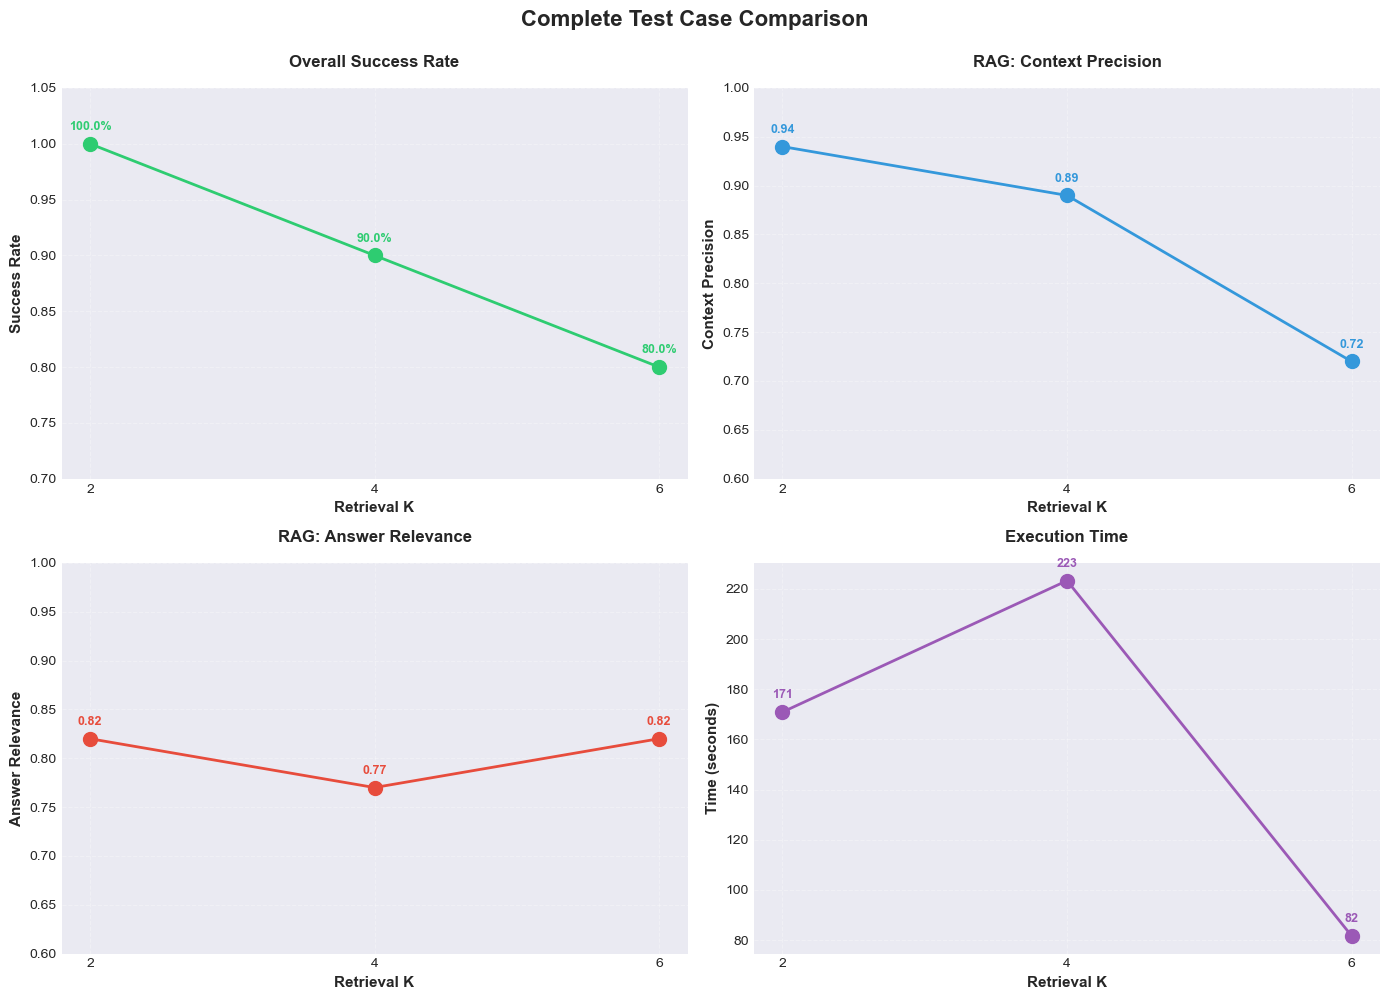

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Complete Test Case Comparison', fontsize=16, fontweight='bold', y=0.995)

# Success Rate
plot_subplot_metric(axes[0, 0], df, 'Retrieval_K', 'Success_Rate', '#2ecc71',
                    'Overall Success Rate', 'Success Rate',
                    annotation_format='.1%', y_lim=(0.7, 1.05))

# Context Precision
plot_subplot_metric(axes[0, 1], df, 'Retrieval_K', 'Context_Precision', '#3498db',
                    'RAG: Context Precision', 'Context Precision',
                    annotation_format='.2f', y_lim=(0.6, 1.0))

# Answer Relevance
plot_subplot_metric(axes[1, 0], df, 'Retrieval_K', 'Answer_Relevance', '#e74c3c',
                    'RAG: Answer Relevance', 'Answer Relevance',
                    annotation_format='.2f', y_lim=(0.6, 1.0))

# Execution Time
plot_subplot_metric(axes[1, 1], df, 'Retrieval_K', 'Time_Seconds', '#9b59b6',
                    'Execution Time', 'Time (seconds)',
                    annotation_format='.0f')

plt.tight_layout()
plt.show()


## Summary Statistics


In [10]:
print("=" * 60)
print("TEST CASE COMPARISON SUMMARY")
print("=" * 60)
print()
for idx, row in df.iterrows():
    print(f"Test {int(row['Test'])} (Retrieval_K={int(row['Retrieval_K'])}):")
    print(f"  Success Rate:     {row['Success_Rate']:.1%} ({int(row['Passed'])}/{int(row['Passed']+row['Failed'])} passed)")
    print(f"  Context Precision: {row['Context_Precision']:.2f}")
    print(f"  Answer Relevance:  {row['Answer_Relevance']:.2f}")
    print(f"  Execution Time:    {row['Time_Seconds']:.1f}s ({row['Time_Minutes']:.2f} min)")
    print()

print("Best Performance:")
best_success = df.loc[df['Success_Rate'].idxmax()]
best_precision = df.loc[df['Context_Precision'].idxmax()]
best_relevance = df.loc[df['Answer_Relevance'].idxmax()]
fastest = df.loc[df['Time_Seconds'].idxmin()]

print(f"  Highest Success Rate:    Test {int(best_success['Test'])} (Retrieval_K={int(best_success['Retrieval_K'])}) - {best_success['Success_Rate']:.1%}")
print(f"  Highest Context Precision: Test {int(best_precision['Test'])} (Retrieval_K={int(best_precision['Retrieval_K'])}) - {best_precision['Context_Precision']:.2f}")
print(f"  Highest Answer Relevance:  Test {int(best_relevance['Test'])} (Retrieval_K={int(best_relevance['Retrieval_K'])}) - {best_relevance['Answer_Relevance']:.2f}")
print(f"  Fastest Execution:        Test {int(fastest['Test'])} (Retrieval_K={int(fastest['Retrieval_K'])}) - {fastest['Time_Seconds']:.1f}s")


TEST CASE COMPARISON SUMMARY

Test 1 (Retrieval_K=2):
  Success Rate:     100.0% (10/10 passed)
  Context Precision: 0.94
  Answer Relevance:  0.82
  Execution Time:    170.9s (2.85 min)

Test 2 (Retrieval_K=4):
  Success Rate:     90.0% (9/10 passed)
  Context Precision: 0.89
  Answer Relevance:  0.77
  Execution Time:    223.3s (3.72 min)

Test 3 (Retrieval_K=6):
  Success Rate:     80.0% (8/10 passed)
  Context Precision: 0.72
  Answer Relevance:  0.82
  Execution Time:    81.7s (1.36 min)

Best Performance:
  Highest Success Rate:    Test 1 (Retrieval_K=2) - 100.0%
  Highest Context Precision: Test 1 (Retrieval_K=2) - 0.94
  Highest Answer Relevance:  Test 1 (Retrieval_K=2) - 0.82
  Fastest Execution:        Test 3 (Retrieval_K=6) - 81.7s
